In [ ]:
# Load Dataset
import pandas as pd


df = pd.read_excel("online_retail_II.xlsx")

# Basic Cleaning
df.dropna(subset=['Customer ID'], inplace=True)
df.drop_duplicates(inplace=True)

# Remove cancellations and non-purchases
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Calculate Total Spend per transaction item
df['TotalSpend'] = df['Quantity'] * df['Price']

# Extract Hour (identify if a customer shops in the morning/evening)
df['Hour'] = df['InvoiceDate'].dt.hour

# AGGREGATE TO CUSTOMER LEVEL (1 row per Customer ID)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days), # Days since last buy
    Frequency=('Invoice', 'nunique'),                                  # Total distinct orders
    Monetary=('TotalSpend', 'sum'),                                    # Total spent
    AvgItemPrice=('Price', 'mean'),                                    # Avg price of items bought
    PreferredHour=('Hour', lambda x: x.mode()[0])                      # Hour they shop most often
).reset_index()

# print(customer_df.info())
print(customer_df.head(10))

   Customer ID  Recency  Frequency  Monetary  AvgItemPrice  PreferredHour
0      12346.0      165         11    372.86      6.253333             13
1      12347.0        3          2   1323.32      2.295070             14
2      12348.0       74          1    222.16      0.719500             14
3      12349.0       43          3   2671.14      8.581765              8
4      12351.0       11          1    300.93      2.355238             15
5      12352.0       11          2    343.80      3.033333             10
6      12353.0       44          1    317.76      1.939000             12
7      12355.0      203          1    488.21      2.399091             11
8      12356.0       16          3   3560.30      3.125663              9
9      12357.0       24          2  12079.99      8.458424             10


In [ ]:
# Preprocess (Standardize the data)
from sklearn.preprocessing import StandardScaler


X = customer_df.drop('Customer ID', axis=1)

X_scaled = StandardScaler()
X_scaled = X_scaled.fit_transform(X)

print(X_scaled)


[[ 0.76229851  0.80108727 -0.18713934 -0.01776133  0.14553294]
 [-0.91040156 -0.3006029  -0.08047459 -0.03722661  0.58132326]
 [-0.17730462 -0.42301292 -0.20405155 -0.04497469  0.58132326]
 ...
 [ 2.114914   -0.42301292 -0.18106351 -0.00745069 -1.16183801]
 [ 0.21505713 -0.3006029  -0.0834923  -0.02749922 -0.72604769]
 [-0.75552193 -0.05578286  0.03426246 -0.03452429 -0.72604769]]


In [44]:
# Model
from sklearn.cluster import KMeans

K_clusters = range(2, 10)
inertia = []

# Using Elbow Method to find the best num. of clusters
for k in K_clusters:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    

In [48]:
# Metrics
from sklearn.metrics import silhouette_score

print("Score for k = 4 : ", silhouette_score(X_scaled, KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)))
print("Score for k = 5 : ", silhouette_score(X_scaled, KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled)))

Score for k = 4 :  0.38598226154840304
Score for k = 5 :  0.35634334956512687


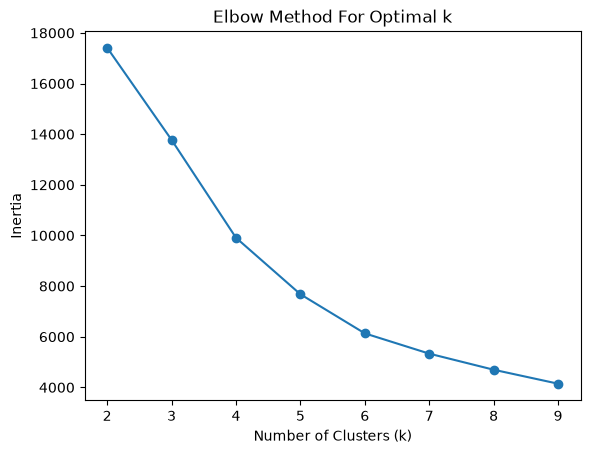

In [47]:
import matplotlib.pyplot as plt

plt.plot(K_clusters, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()